In [137]:
words = open('names.txt', 'r', encoding="utf-8").read().splitlines()

In [138]:
import re
cleaned_words = []
for w in words:
    w = w.strip().lower()
    w = re.sub(r'[^a-z]', '', w)
    if w:
        cleaned_words.append(w)
chars = sorted(list(set(''.join(cleaned_words))))
print(f"Unique characters: {len(chars)}")  # Should be close to 26

Unique characters: 26


In [139]:
min(len(w) for w in cleaned_words)

1

In [140]:
max(len(w) for w in cleaned_words)

27

In [141]:
b = {}
for w in cleaned_words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

In [142]:
sorted(b.items(), key=lambda kv: -kv[1])

[(('e', '<E>'), 825),
 (('s', '<E>'), 689),
 (('e', 'r'), 674),
 (('<S>', 's'), 652),
 (('i', 'n'), 613),
 (('a', 'r'), 551),
 (('a', '<E>'), 499),
 (('r', 'e'), 487),
 (('<S>', 'c'), 475),
 (('a', 'n'), 471),
 (('t', '<E>'), 456),
 (('<S>', 'a'), 442),
 (('s', 't'), 429),
 (('o', 'n'), 427),
 (('r', 'a'), 406),
 (('t', 'e'), 396),
 (('e', 'n'), 396),
 (('<S>', 'm'), 379),
 (('o', '<E>'), 373),
 (('e', 's'), 369),
 (('o', 'r'), 368),
 (('a', 'l'), 362),
 (('t', 'i'), 351),
 (('l', 'e'), 351),
 (('<S>', 'p'), 349),
 (('<S>', 't'), 346),
 (('<S>', 'b'), 344),
 (('c', 'o'), 342),
 (('r', '<E>'), 340),
 (('r', 'o'), 324),
 (('n', '<E>'), 322),
 (('n', 'e'), 321),
 (('t', 'a'), 321),
 (('l', 'i'), 320),
 (('r', 'i'), 315),
 (('a', 't'), 314),
 (('d', 'e'), 312),
 (('m', 'a'), 307),
 (('n', 't'), 306),
 (('e', 'l'), 289),
 (('y', '<E>'), 288),
 (('l', 'a'), 284),
 (('i', 'c'), 283),
 (('c', 'a'), 276),
 (('e', 'a'), 276),
 (('a', 's'), 271),
 (('i', 't'), 269),
 (('m', 'e'), 264),
 (('t', 'r

In [143]:
import torch

In [144]:
N = torch.zeros((27, 27), dtype=torch.int32)

In [145]:
chars = sorted(list(set(''.join(cleaned_words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}

In [146]:
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [147]:
for w in cleaned_words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

In [148]:
import matplotlib.pyplot as plt
%matplotlib inline

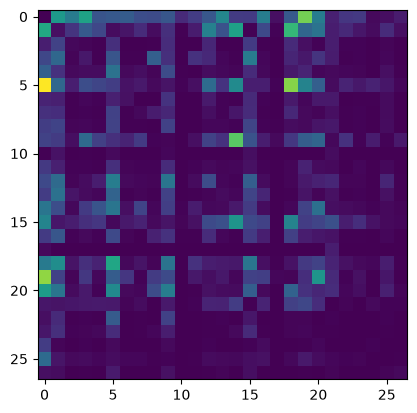

In [149]:
plt.imshow(N)

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

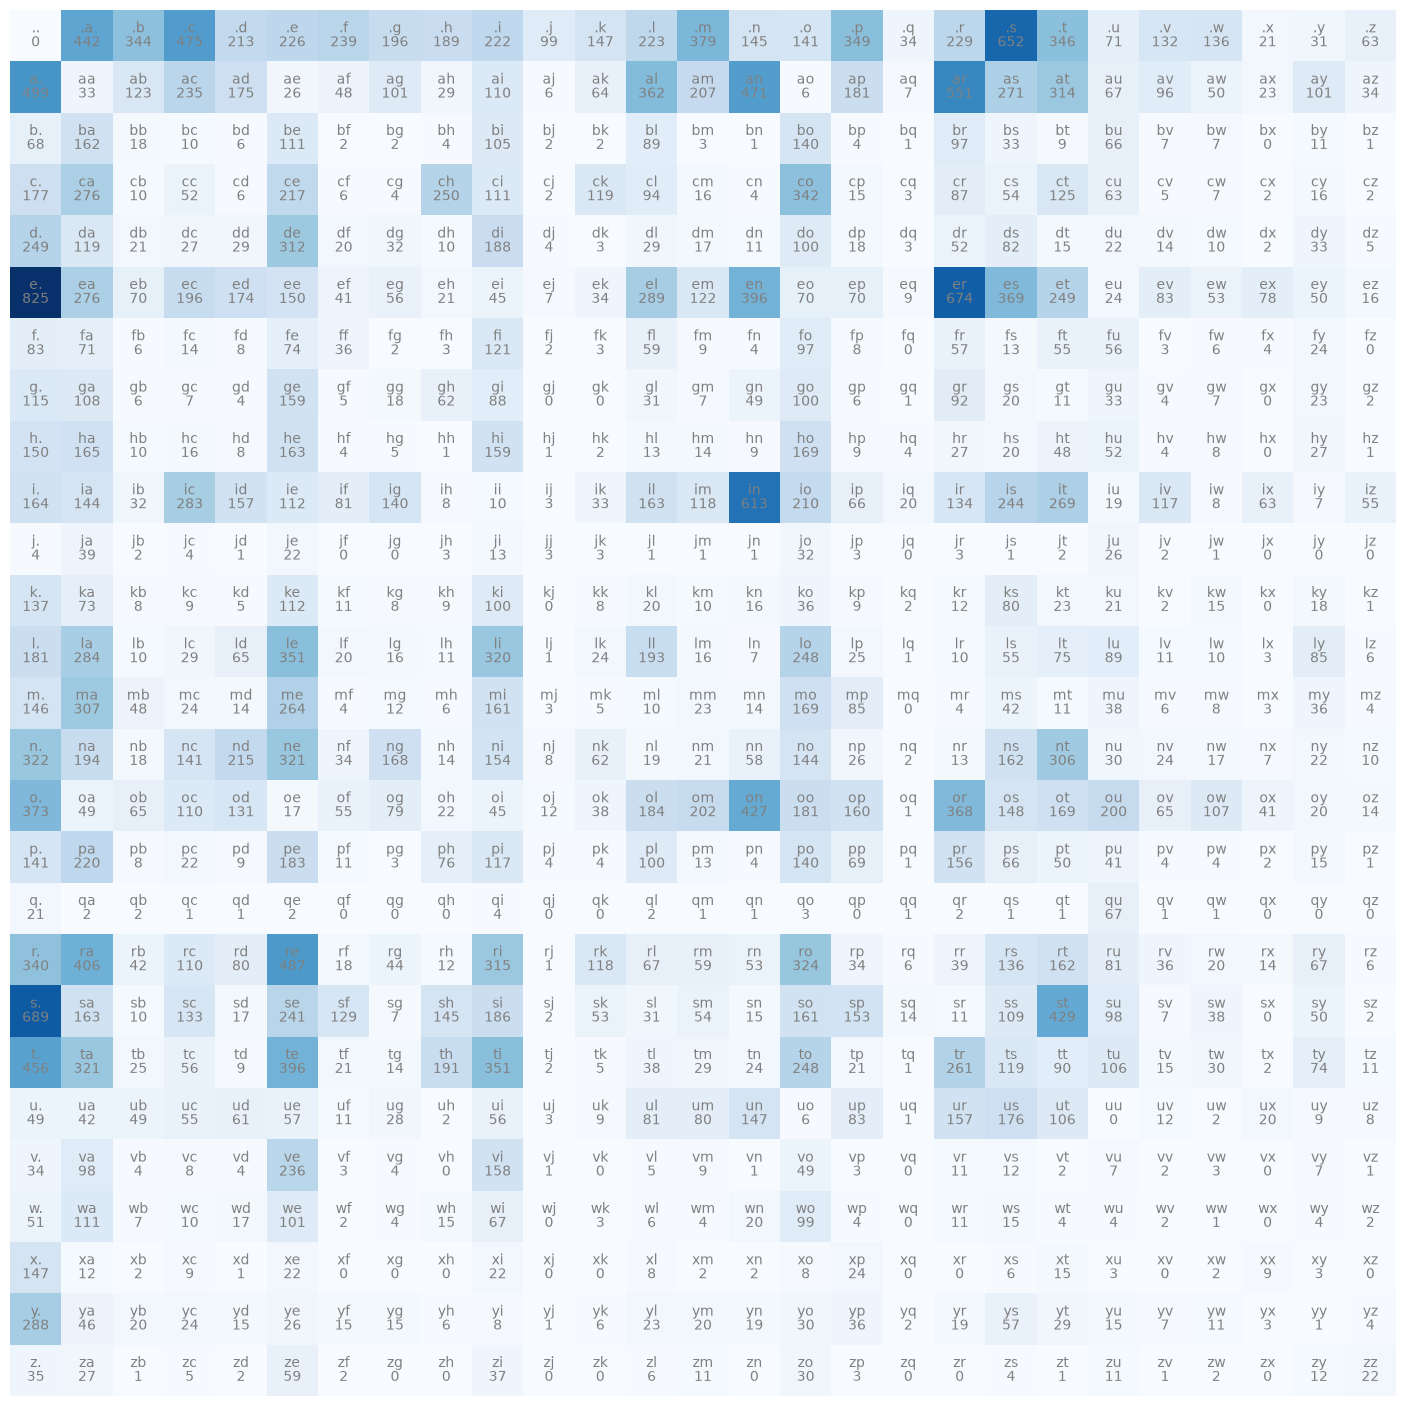

In [150]:
plt.figure(figsize = (18, 18))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color="gray")
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color="gray")

plt.axis('off')

In [151]:
N[0]

tensor([  0, 442, 344, 475, 213, 226, 239, 196, 189, 222,  99, 147, 223, 379,
        145, 141, 349,  34, 229, 652, 346,  71, 132, 136,  21,  31,  63],
       dtype=torch.int32)

In [152]:
p = N[0].float()
p = p/p.sum()
p

tensor([0.0000, 0.0769, 0.0599, 0.0827, 0.0371, 0.0393, 0.0416, 0.0341, 0.0329,
        0.0386, 0.0172, 0.0256, 0.0388, 0.0660, 0.0252, 0.0245, 0.0608, 0.0059,
        0.0399, 0.1135, 0.0602, 0.0124, 0.0230, 0.0237, 0.0037, 0.0054, 0.0110])

In [206]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
itos[ix]

'c'

In [239]:
g = torch.Generator().manual_seed(2147483647)

# for i in range(10):
ix = 0
out = []
while True:
    p = N[ix].float()
    p = p/p.sum()
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
        break
print("".join(out))

cex.
